# CIFAR-100 — Interpolation Experiments (Bilinear vs. Bicubic vs. Lanczos)

This notebook tests the effectiveness of different image upscaling interpolation methods on a pre-trained **ResNet-34** transfer learning setup.

We compare three upscaling interpolation methods to go from native 32×32 CIFAR-100 images to 224×224:
1. **Bilinear** (Current baseline default)
2. **Bicubic** (Sharper edges, less blur)
3. **Lanczos** (High-quality sinc-based interpolation)

To ensure a quick and controlled experiment, we train each setting for **30 epochs total**:
- **Phase 1** — 10 epochs with frozen backbone (head warm-up)
- **Phase 2** — 20 epochs with fully unfrozen network (fine-tuning)


## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch import optim
from torch.amp import GradScaler

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch


## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')


Using device: cuda


## Experiment Runner Helper

We encapsulate the training pipeline to run the comparative experiments under identical conditions.

In [3]:
def run_interpolation_experiment(interpolation_mode, mode_name, phase2_epochs=20):
    print(f"\n" + "="*60)
    print(f" STARTING EXPERIMENT: {mode_name}")
    print(f"" + "="*60 + "\n")
    
    # 1. Dataloaders with custom interpolation
    trainloader, valloader, testloader = get_cifar100_dataloaders(
        batch_size=64,
        num_workers=4,
        img_size=224,
        use_imagenet_stats=True,
        interpolation=interpolation_mode
    )
    
    # 2. Model setup (ResNet-34)
    model = models.resnet34(weights='DEFAULT')
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 100)
    model = model.to(device)
    
    # 3. Phase 1 - Head only
    for name, param in model.named_parameters():
        if "fc" not in name:
            param.requires_grad = False
        
    PHASE1_EPOCHS = 10
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler = GradScaler('cuda')
    
    optimizer_p1 = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3,
        weight_decay=1e-4,
    )
    scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=1e-5
    )
    
    checkpoint_p1 = ModelCheckpoint(
        model=model,
        checkpoint_path=f'../../checkpoint/resnet34_interp_{mode_name}_phase1_last.pth',
        best_model_path=f'../../checkpoint/resnet34_interp_{mode_name}_phase1_best.pth',
        mode='max',
        verbose=False,
    )
    
    print("Starting Phase 1 (Head Warm-up)...")
    fit(
        model, trainloader, valloader, criterion,
        optimizer_p1, scheduler_p1, scaler, device,
        PHASE1_EPOCHS, checkpoint_p1,
        step_scheduler_per_batch=False,
    )
    
    # 4. Phase 2 - Fine-tuning
    for param in model.parameters():
        param.requires_grad = True
        
    checkpoint_p1.restore_best_weights()
    
    optimizer_p2 = optim.Adam(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4,
    )
    scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_p2, T_max=phase2_epochs, eta_min=1e-6
    )
    
    checkpoint_p2 = ModelCheckpoint(
        model=model,
        checkpoint_path=f'../../checkpoint/resnet34_interp_{mode_name}_phase2_last.pth',
        best_model_path=f'../../checkpoint/resnet34_interp_{mode_name}_phase2_best.pth',
        mode='max',
        verbose=True,
    )
    
    print("Starting Phase 2 (Full Fine-tuning)...")
    train_losses, val_losses, val_accs = fit(
        model, trainloader, valloader, criterion,
        optimizer_p2, scheduler_p2, scaler, device,
        phase2_epochs, checkpoint_p2,
        step_scheduler_per_batch=False,
    )
    
    # 5. Evaluate on Test Set
    checkpoint_p2.restore_best_weights()
    test_acc, _ = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
    print(f"\nExperiment {mode_name} Finished!")
    print(f"Best Val Acc: {max(val_accs):.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%\n")
    
    return train_losses, val_losses, val_accs, test_acc


## Run 1: BILINEAR (Baseline default)

In [4]:
tr_loss_bilinear, val_loss_bilinear, val_acc_bilinear, test_acc_bilinear = run_interpolation_experiment(
    interpolation_mode=transforms.InterpolationMode.BILINEAR,
    mode_name='BILINEAR',
    phase2_epochs=20
)



 STARTING EXPERIMENT: BILINEAR



C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Starting Phase 1 (Head Warm-up)...
Epoch [ 1/10]  Train Loss: 3.4213  Val Loss: 2.3924  Val Acc: 53.01%  LR: 0.000976  Time: 37.23s
Epoch [ 2/10]  Train Loss: 2.8370  Val Loss: 2.2515  Val Acc: 56.15%  LR: 0.000905  Time: 18.60s
Epoch [ 3/10]  Train Loss: 2.7261  Val Loss: 2.1931  Val Acc: 57.83%  LR: 0.000796  Time: 18.21s
Epoch [ 4/10]  Train Loss: 2.6790  Val Loss: 2.1795  Val Acc: 58.51%  LR: 0.000658  Time: 18.30s
Epoch [ 5/10]  Train Loss: 2.6284  Val Loss: 2.1515  Val Acc: 59.75%  LR: 0.000505  Time: 18.28s
Epoch [ 6/10]  Train Loss: 2.5960  Val Loss: 2.1083  Val Acc: 61.03%  LR: 0.000352  Time: 18.22s
Epoch [ 7/10]  Train Loss: 2.5767  Val Loss: 2.1007  Val Acc: 61.39%  LR: 0.000214  Time: 18.44s
Epoch [ 8/10]  Train Loss: 2.5479  Val Loss: 2.0902  Val Acc: 61.68%  LR: 0.000105  Time: 18.48s
Epoch [ 9/10]  Train Loss: 2.5463  Val Loss: 2.0827  Val Acc: 62.22%  LR: 0.000034  Time: 18.38s
Epoch [10/10]  Train Loss: 2.5324  Val Loss: 2.0813  Val Acc: 62.04%  LR: 0.000010  Time: 18

## Run 2: BICUBIC

In [5]:
tr_loss_bicubic, val_loss_bicubic, val_acc_bicubic, test_acc_bicubic = run_interpolation_experiment(
    interpolation_mode=transforms.InterpolationMode.BICUBIC,
    mode_name='BICUBIC',
    phase2_epochs=20
)



 STARTING EXPERIMENT: BICUBIC

Starting Phase 1 (Head Warm-up)...
Epoch [ 1/10]  Train Loss: 3.4149  Val Loss: 2.4378  Val Acc: 50.86%  LR: 0.000976  Time: 34.26s
Epoch [ 2/10]  Train Loss: 2.8146  Val Loss: 2.2763  Val Acc: 55.91%  LR: 0.000905  Time: 19.44s
Epoch [ 3/10]  Train Loss: 2.7133  Val Loss: 2.2079  Val Acc: 57.76%  LR: 0.000796  Time: 19.22s
Epoch [ 4/10]  Train Loss: 2.6586  Val Loss: 2.1703  Val Acc: 58.95%  LR: 0.000658  Time: 19.37s
Epoch [ 5/10]  Train Loss: 2.6203  Val Loss: 2.1464  Val Acc: 59.38%  LR: 0.000505  Time: 19.31s
Epoch [ 6/10]  Train Loss: 2.5819  Val Loss: 2.1303  Val Acc: 60.40%  LR: 0.000352  Time: 19.15s
Epoch [ 7/10]  Train Loss: 2.5551  Val Loss: 2.1209  Val Acc: 60.59%  LR: 0.000214  Time: 19.39s
Epoch [ 8/10]  Train Loss: 2.5387  Val Loss: 2.0932  Val Acc: 61.17%  LR: 0.000105  Time: 19.38s
Epoch [ 9/10]  Train Loss: 2.5165  Val Loss: 2.0924  Val Acc: 61.47%  LR: 0.000034  Time: 19.45s
Epoch [10/10]  Train Loss: 2.5042  Val Loss: 2.0911  Val Acc

## Run 3: LANCZOS

In [6]:
tr_loss_lanczos, val_loss_lanczos, val_acc_lanczos, test_acc_lanczos = run_interpolation_experiment(
    interpolation_mode=transforms.InterpolationMode.LANCZOS,
    mode_name='LANCZOS',
    phase2_epochs=20
)



 STARTING EXPERIMENT: LANCZOS

Starting Phase 1 (Head Warm-up)...
Epoch [ 1/10]  Train Loss: 3.4012  Val Loss: 2.4167  Val Acc: 52.17%  LR: 0.000976  Time: 35.41s
Epoch [ 2/10]  Train Loss: 2.7962  Val Loss: 2.2552  Val Acc: 56.32%  LR: 0.000905  Time: 20.44s
Epoch [ 3/10]  Train Loss: 2.6977  Val Loss: 2.1980  Val Acc: 57.95%  LR: 0.000796  Time: 20.46s
Epoch [ 4/10]  Train Loss: 2.6381  Val Loss: 2.1730  Val Acc: 59.18%  LR: 0.000658  Time: 20.64s
Epoch [ 5/10]  Train Loss: 2.6051  Val Loss: 2.1524  Val Acc: 60.15%  LR: 0.000505  Time: 20.61s
Epoch [ 6/10]  Train Loss: 2.5656  Val Loss: 2.1225  Val Acc: 61.07%  LR: 0.000352  Time: 20.74s
Epoch [ 7/10]  Train Loss: 2.5393  Val Loss: 2.1205  Val Acc: 61.05%  LR: 0.000214  Time: 20.64s
Epoch [ 8/10]  Train Loss: 2.5174  Val Loss: 2.1009  Val Acc: 61.90%  LR: 0.000105  Time: 20.74s
Epoch [ 9/10]  Train Loss: 2.5016  Val Loss: 2.0993  Val Acc: 61.88%  LR: 0.000034  Time: 20.61s
Epoch [10/10]  Train Loss: 2.4973  Val Loss: 2.0888  Val Acc

## Results Comparison

 FINAL EXPERIMENT COMPARISON
BILINEAR Test Accuracy: 85.37% | Best Val: 85.62%
BICUBIC  Test Accuracy: 85.78% | Best Val: 85.69%
LANCZOS  Test Accuracy: 85.89% | Best Val: 85.77%


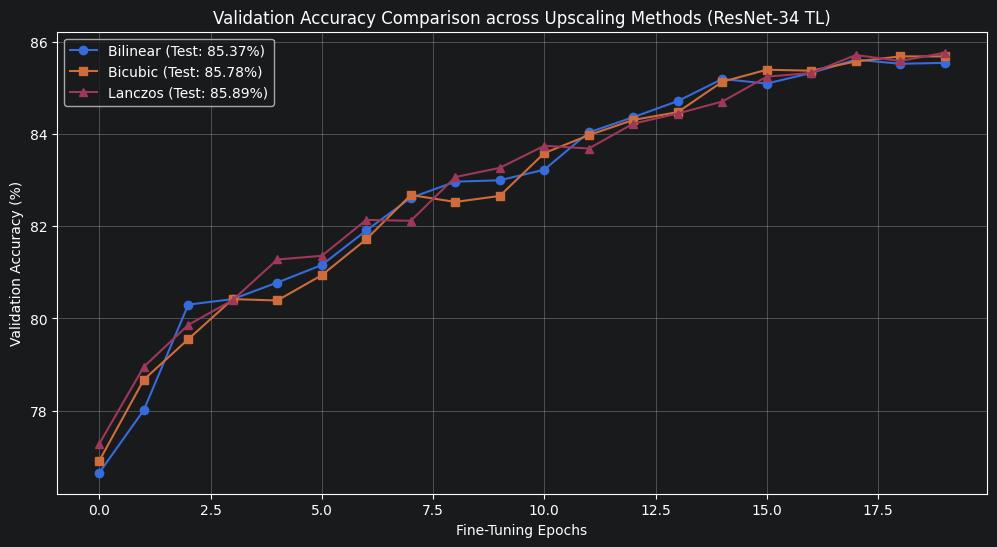

In [7]:
import matplotlib.pyplot as plt

print("==================================================")
print(" FINAL EXPERIMENT COMPARISON")
print("==================================================")
print(f"BILINEAR Test Accuracy: {test_acc_bilinear:.2f}% | Best Val: {max(val_acc_bilinear):.2f}%")
print(f"BICUBIC  Test Accuracy: {test_acc_bicubic:.2f}% | Best Val: {max(val_acc_bicubic):.2f}%")
print(f"LANCZOS  Test Accuracy: {test_acc_lanczos:.2f}% | Best Val: {max(val_acc_lanczos):.2f}%")
print("==================================================")

# Plot validation accuracies
plt.figure(figsize=(12, 6))
plt.plot(val_acc_bilinear, label=f'Bilinear (Test: {test_acc_bilinear:.2f}%)', marker='o')
plt.plot(val_acc_bicubic, label=f'Bicubic (Test: {test_acc_bicubic:.2f}%)', marker='s')
plt.plot(val_acc_lanczos, label=f'Lanczos (Test: {test_acc_lanczos:.2f}%)', marker='^')
plt.title('Validation Accuracy Comparison across Upscaling Methods (ResNet-34 TL)')
plt.xlabel('Fine-Tuning Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()
